# Unemployment Analysis in India
## Exploratory Data Analysis with Focus on COVID-19 Impact

**Objective:** Analyze unemployment trends across Indian regions and time periods, with special focus on pre/post-COVID impact.

**Tech Stack:** Python, pandas, matplotlib, seaborn

**Dataset:** [Unemployment in India](https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india) (Kaggle)

---

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("done")

done


In [33]:
import os

possible_filenames = [
    'Unemployment in India.csv',
    'Unemployment_Rate_upto_11_2020.csv',
    'unemployment-in-india.csv',
    'unemployment.csv'
]

df = None
loaded_file = None

for fname in possible_filenames:
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        loaded_file = fname
        print(f"Loaded: {fname}")
        break

if df is None:
    files = [f for f in os.listdir('.') if f.endswith('.csv')]
    print(" Could not find the dataset CSV file.")
    print(f"   CSV files found in this folder: {files}")
else:
    print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nColumn names:")
    print(df.columns.tolist())

Loaded: Unemployment in India.csv

Dataset shape: 768 rows × 7 columns

Column names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [34]:
print("=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== BASIC INFO ===")
print(df.info())

=== FIRST 5 ROWS ===


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural



=== DATA TYPES ===
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 n

In [35]:

print("=== NULL VALUE COUNTS ===")
null_counts = df.isnull().sum()
print(null_counts)
print(f"\nTotal null values: {null_counts.sum()}")

print("\n=== NULL PERCENTAGE ===")
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(null_pct)

duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

if null_counts.sum() > 0:
    print("\n  Null values detected. Will handle in cleaning step.")
else:
    print("\n No null values found.")

=== NULL VALUE COUNTS ===
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Total null values: 196

=== NULL PERCENTAGE ===
Region                                      3.65
 Date                                       3.65
 Frequency                                  3.65
 Estimated Unemployment Rate (%)            3.65
 Estimated Employed                         3.65
 Estimated Labour Participation Rate (%)    3.65
Area                                        3.65
dtype: float64

Duplicate rows: 27

  Null values detected. Will handle in cleaning step.


In [36]:

df_clean = df.copy()

df_clean.columns = df_clean.columns.str.strip()
print("Cleaned column names:")
print(df_clean.columns.tolist())

if df_clean.isnull().sum().sum() > 0:
    print(f"\nDropping {df_clean.isnull().sum().sum()} null values...")
    df_clean = df_clean.dropna()
    print(f"Shape after dropping nulls: {df_clean.shape}")

col_mapping = {}
for col in df_clean.columns:
    lower = col.lower().replace(' ', '_').replace('-', '_')
    if 'region' in lower and 'state' in lower:
        col_mapping[col] = 'region'
    elif 'region' in lower:
        col_mapping[col] = 'region'
    elif 'state' in lower:
        col_mapping[col] = 'region'
    elif 'date' in lower:
        col_mapping[col] = 'date'
    elif 'unemployment' in lower and 'rate' in lower:
        col_mapping[col] = 'unemployment_rate'
    elif 'employed' in lower:
        col_mapping[col] = 'employed'
    elif 'labour' in lower or 'labor' in lower:
        col_mapping[col] = 'labour_participation_rate'
    elif 'area' in lower:
        col_mapping[col] = 'area'
    elif 'frequency' in lower:
        col_mapping[col] = 'frequency'

df_clean = df_clean.rename(columns=col_mapping)
print("\nRenamed columns:")
print(df_clean.columns.tolist())

if 'date' in df_clean.columns:
    try:
        df_clean['date'] = pd.to_datetime(df_clean['date'], dayfirst=True)
    except:
        try:
            df_clean['date'] = pd.to_datetime(df_clean['date'])
        except Exception as e:
            print(f"Date parsing error: {e}")
    print(f"\nDate range: {df_clean['date'].min()} to {df_clean['date'].max()}")

numeric_cols = ['unemployment_rate', 'employed', 'labour_participation_rate']
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        print(f"Converted {col} to numeric")

print(f"\n Cleaned dataset shape: {df_clean.shape}")
print("\nCleaned data sample:")
display(df_clean.head())

Cleaned column names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

Dropping 196 null values...
Shape after dropping nulls: (740, 7)

Renamed columns:
['region', 'date', 'frequency', 'unemployment_rate', 'employed', 'labour_participation_rate', 'area']

Date range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00
Converted unemployment_rate to numeric
Converted employed to numeric
Converted labour_participation_rate to numeric

 Cleaned dataset shape: (740, 7)

Cleaned data sample:


,region,date,frequency,unemployment_rate,employed,labour_participation_rate,area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [37]:

print("=== NUMERIC COLUMNS SUMMARY ===")
numeric_summary = df_clean.select_dtypes(include=[np.number]).describe().round(2)
display(numeric_summary)

print("\n=== CATEGORICAL COLUMNS ===")
for col in df_clean.select_dtypes(include=['object']).columns:
    print(f"\n{col}: {df_clean[col].nunique()} unique values")
    print(df_clean[col].value_counts().head(10))

=== NUMERIC COLUMNS SUMMARY ===


,unemployment_rate,employed,labour_participation_rate
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57



=== CATEGORICAL COLUMNS ===

region: 28 unique values
region
Andhra Pradesh      28
Bihar               28
Chhattisgarh        28
Delhi               28
Karnataka           28
Gujarat             28
Haryana             28
Himachal Pradesh    28
Jharkhand           28
Maharashtra         28
Name: count, dtype: int64

frequency: 2 unique values
frequency
Monthly     381
 Monthly    359
Name: count, dtype: int64

area: 2 unique values
area
Urban    381
Rural    359
Name: count, dtype: int64


=== AVERAGE UNEMPLOYMENT RATE BY REGION ===
region
Tripura             28.35
Haryana             26.28
Jharkhand           20.58
Bihar               18.92
Himachal Pradesh    18.54
Delhi               16.50
Jammu & Kashmir     16.19
Chandigarh          15.99
Rajasthan           14.06
Uttar Pradesh       12.55
Punjab              12.03
Puducherry          10.22
Kerala              10.12
Tamil Nadu           9.28
Goa                  9.27
Chhattisgarh         9.24
West Bengal          8.12
Telangana            7.74
Maharashtra          7.56
Andhra Pradesh       7.48
Madhya Pradesh       7.41
Sikkim               7.25
Karnataka            6.68
Gujarat              6.66
Uttarakhand          6.58
Assam                6.43
Odisha               5.66
Meghalaya            4.80
Name: unemployment_rate, dtype: float64


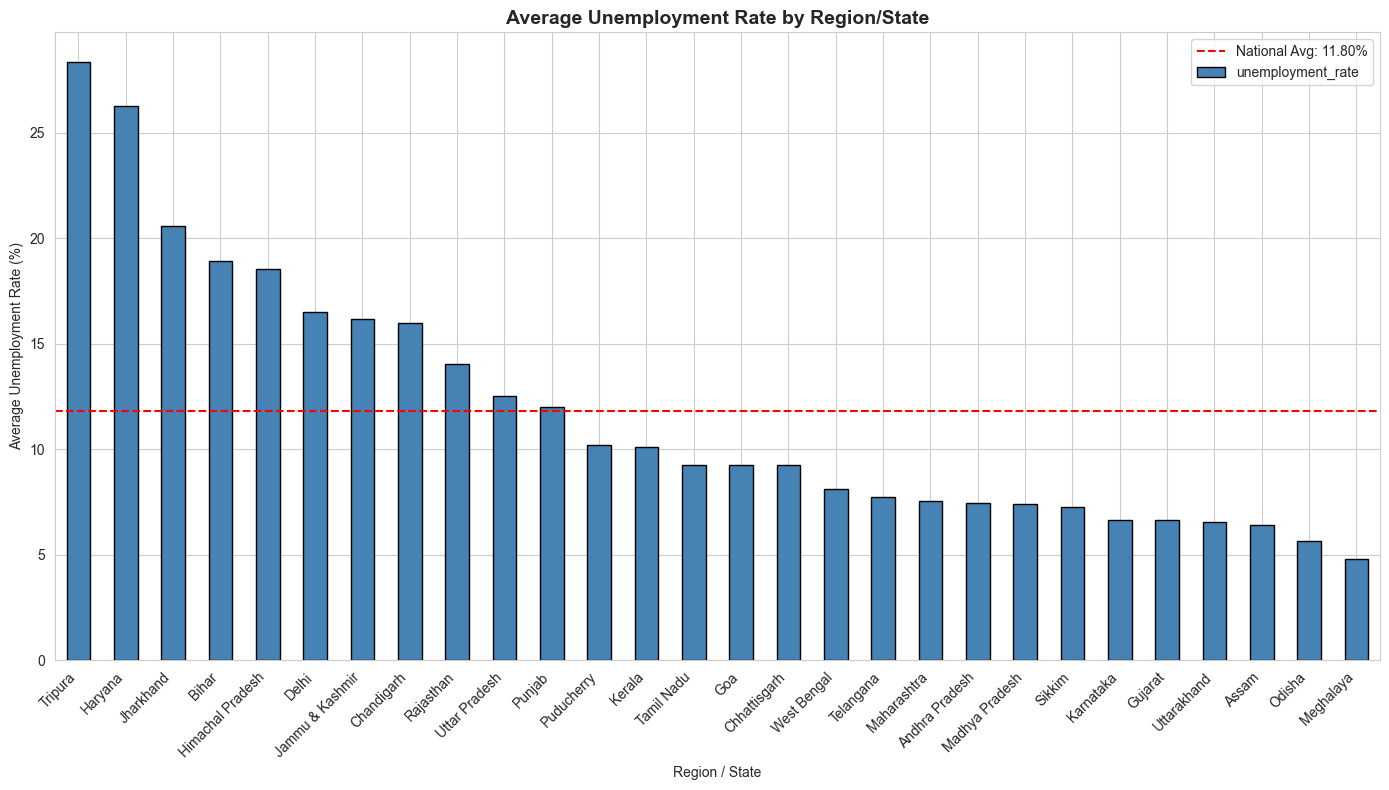


 National average unemployment rate: 11.80%
   Highest: Tripura (28.35%)
   Lowest:  Meghalaya (4.8%)


In [38]:

if 'region' in df_clean.columns and 'unemployment_rate' in df_clean.columns:
    region_avg = df_clean.groupby('region')['unemployment_rate'].mean().sort_values(ascending=False).round(2)
    
    print("=== AVERAGE UNEMPLOYMENT RATE BY REGION ===")
    print(region_avg)
    
    plt.figure(figsize=(14, 8))
    region_avg.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Average Unemployment Rate by Region/State', fontsize=14, fontweight='bold')
    plt.xlabel('Region / State')
    plt.ylabel('Average Unemployment Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.axhline(y=region_avg.mean(), color='red', linestyle='--', label=f'National Avg: {region_avg.mean():.2f}%')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"\n National average unemployment rate: {region_avg.mean():.2f}%")
    print(f"   Highest: {region_avg.index[0]} ({region_avg.iloc[0]}%)")
    print(f"   Lowest:  {region_avg.index[-1]} ({region_avg.iloc[-1]}%)")
else:
    print(" Required columns not found. Available columns:")
    print(df_clean.columns.tolist())

=== MONTHLY AVERAGE UNEMPLOYMENT RATE ===
year_month
2019-05     8.87
2019-06     9.30
2019-07     9.03
2019-08     9.64
2019-09     9.05
2019-10     9.90
2019-11     9.87
2019-12     9.50
2020-01     9.95
2020-02     9.96
2020-03    10.70
2020-04    23.64
2020-05    24.88
2020-06    11.90
Freq: M, Name: unemployment_rate, dtype: float64


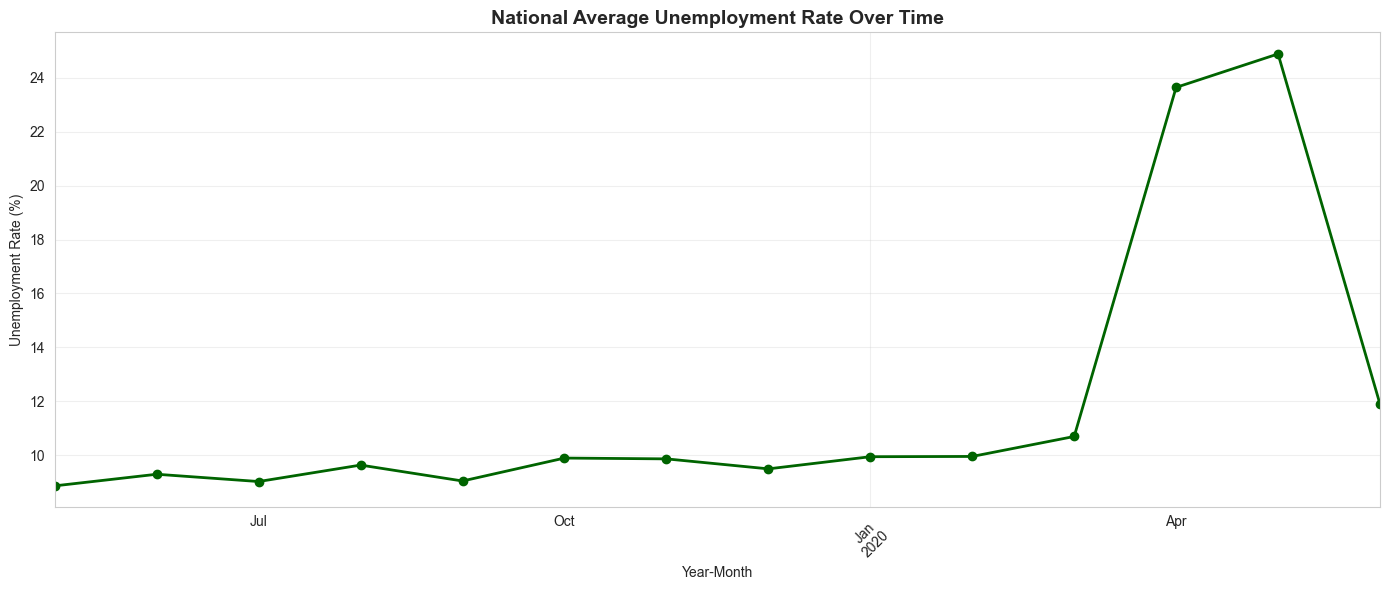


 Observe the trend — look for spikes around March 2020 onwards (COVID impact).


In [39]:

if 'date' in df_clean.columns and 'unemployment_rate' in df_clean.columns:
    df_clean['year_month'] = df_clean['date'].dt.to_period('M')
    
    monthly_avg = df_clean.groupby('year_month')['unemployment_rate'].mean().round(2)
    
    print("=== MONTHLY AVERAGE UNEMPLOYMENT RATE ===")
    print(monthly_avg)
    
    plt.figure(figsize=(14, 6))
    monthly_avg.plot(kind='line', marker='o', color='darkgreen', linewidth=2, markersize=6)
    plt.title('National Average Unemployment Rate Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Year-Month')
    plt.ylabel('Unemployment Rate (%)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n Observe the trend — look for spikes around March 2020 onwards (COVID impact).")
else:
    print(" Date column not available for time-series analysis.")

Selected states for time-series: ['Maharashtra', 'Uttar Pradesh', 'Kerala']


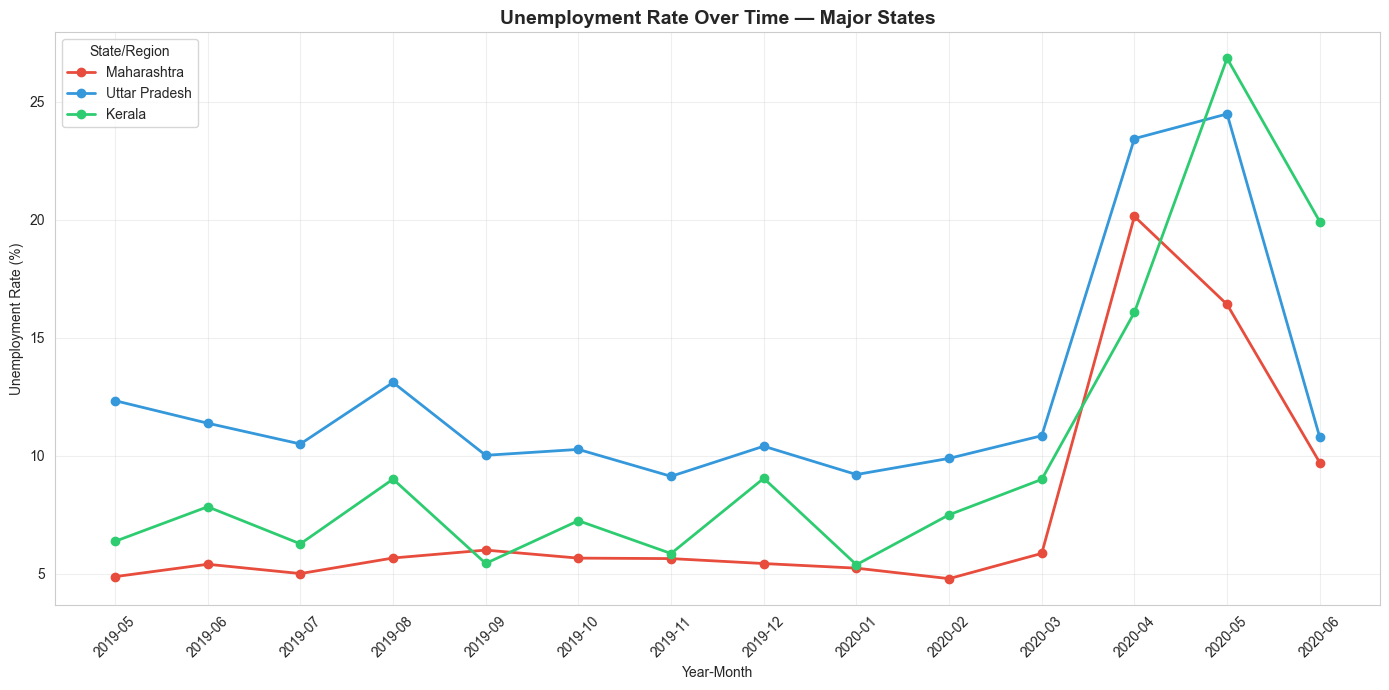


 Look for:
    Sharp spikes around March-April 2020 (COVID lockdown)
    Which state recovered fastest post-lockdown
    Seasonal patterns before vs. after COVID


In [40]:

if 'region' in df_clean.columns and 'date' in df_clean.columns:
    top_states = df_clean.groupby('region')['unemployment_rate'].mean().sort_values(ascending=False).head(5).index.tolist()
    
    well_known = ['Maharashtra', 'Uttar Pradesh', 'Kerala', 'Tamil Nadu', 'West Bengal',
                  'Delhi', 'Bihar', 'Rajasthan', 'Karnataka', 'Gujarat']
    available_known = [s for s in well_known if s in df_clean['region'].unique()]
    
    selected_states = available_known[:3] if len(available_known) >= 3 else top_states[:3]
    
    print(f"Selected states for time-series: {selected_states}")
    
    plt.figure(figsize=(14, 7))
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
    
    for i, state in enumerate(selected_states):
        state_data = df_clean[df_clean['region'] == state].copy()
        state_data = state_data.sort_values('date')
        state_monthly = state_data.groupby(state_data['date'].dt.to_period('M'))['unemployment_rate'].mean()
        
        plt.plot(state_monthly.index.astype(str), state_monthly.values,
                 marker='o', label=state, color=colors[i % len(colors)], linewidth=2)
    
    plt.title('Unemployment Rate Over Time — Major States', fontsize=14, fontweight='bold')
    plt.xlabel('Year-Month')
    plt.ylabel('Unemployment Rate (%)')
    plt.legend(title='State/Region', loc='upper left')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n Look for:")
    print("    Sharp spikes around March-April 2020 (COVID lockdown)")
    print("    Which state recovered fastest post-lockdown")
    print("    Seasonal patterns before vs. after COVID")
else:
    print(" Required columns not available.")

=== TOP 10 STATES BY AVERAGE UNEMPLOYMENT RATE ===
   1. Tripura: 28.35%
   2. Haryana: 26.28%
   3. Jharkhand: 20.58%
   4. Bihar: 18.92%
   5. Himachal Pradesh: 18.54%
   6. Delhi: 16.5%
   7. Jammu & Kashmir: 16.19%
   8. Chandigarh: 15.99%
   9. Rajasthan: 14.06%
  10. Uttar Pradesh: 12.55%


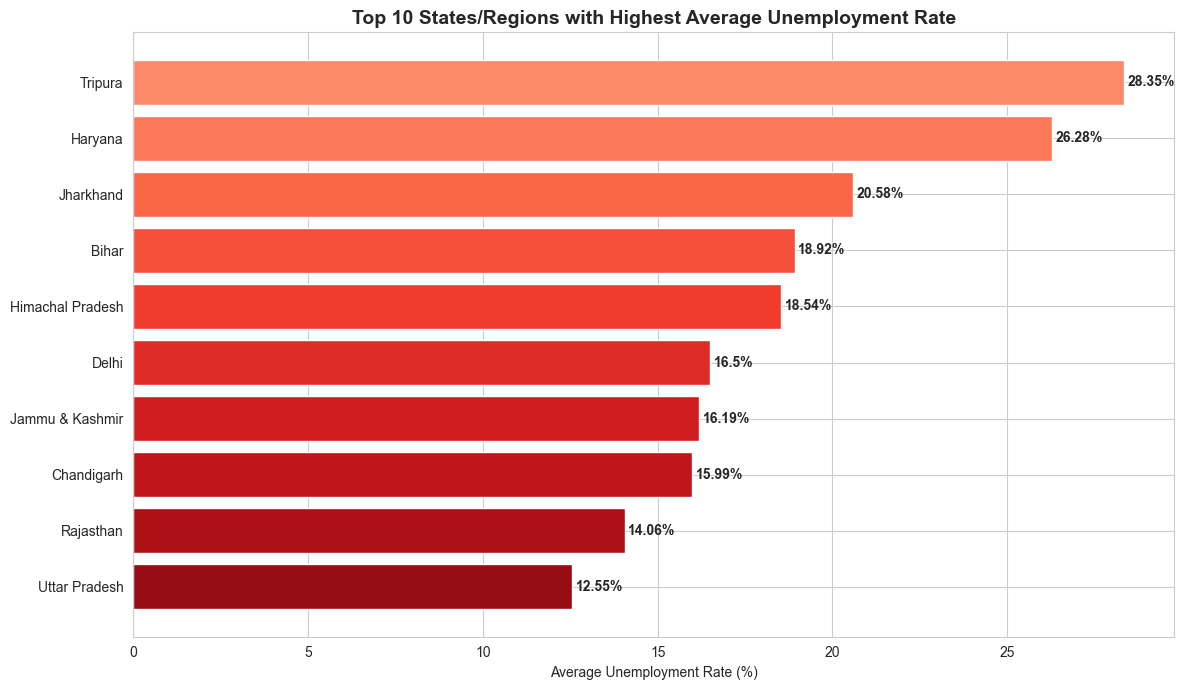


 Tripura has the highest average unemployment at 28.35%.


In [41]:

if 'region' in df_clean.columns and 'unemployment_rate' in df_clean.columns:
    top10 = df_clean.groupby('region')['unemployment_rate'].mean().sort_values(ascending=False).head(10).round(2)
    
    print("=== TOP 10 STATES BY AVERAGE UNEMPLOYMENT RATE ===")
    for i, (state, rate) in enumerate(top10.items(), 1):
        print(f"  {i:2d}. {state}: {rate}%")
    
    # Plot
    plt.figure(figsize=(12, 7))
    bars = plt.barh(range(len(top10)), top10.values, color=plt.cm.Reds(np.linspace(0.4, 0.9, len(top10))))
    plt.yticks(range(len(top10)), top10.index)
    plt.xlabel('Average Unemployment Rate (%)')
    plt.title('Top 10 States/Regions with Highest Average Unemployment Rate', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()

    for i, (bar, val) in enumerate(zip(bars, top10.values)):
        plt.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val}%',
                va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n {top10.index[0]} has the highest average unemployment at {top10.iloc[0]}%.")
else:
    print(" Required columns not available.")

Available numeric columns: ['unemployment_rate', 'employed', 'labour_participation_rate']


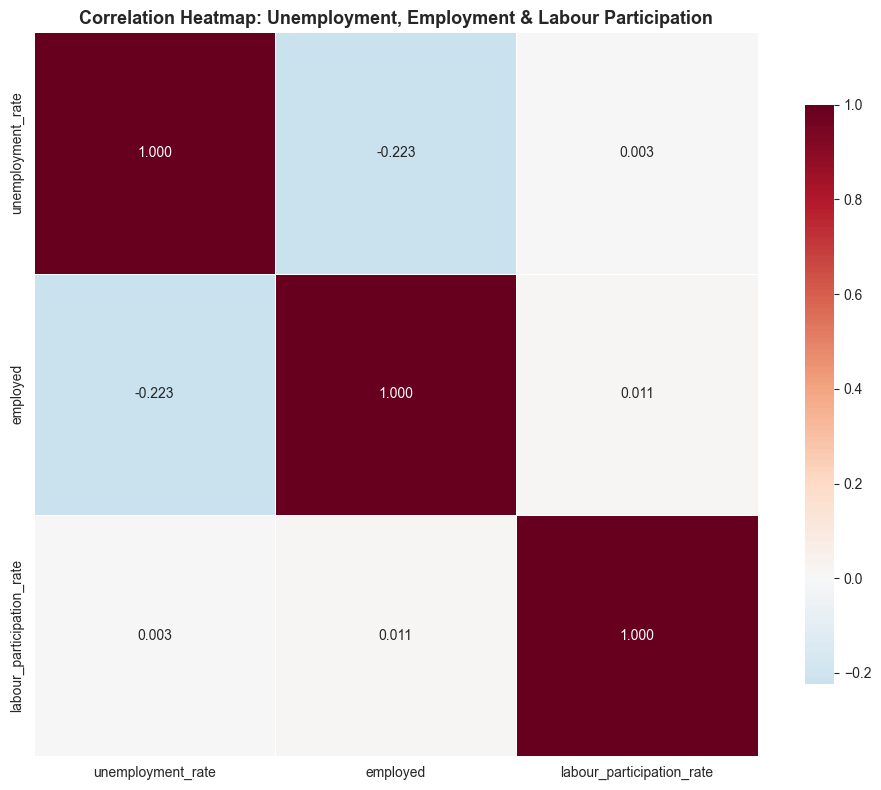


 Interpretation:
   Values close to +1: Strong positive correlation
   Values close to -1: Strong negative correlation
   Values near 0: Weak/no correlation

Strongest correlations:
   • unemployment_rate ↔ employed: -0.223
   • employed ↔ labour_participation_rate: 0.011
   • unemployment_rate ↔ labour_participation_rate: 0.003


In [42]:

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Available numeric columns: {numeric_cols}")

target_cols = []
for col in numeric_cols:
    name = col.lower()
    if any(keyword in name for keyword in ['unemployment', 'employed', 'labour', 'labor', 'participation']):
        target_cols.append(col)

if len(target_cols) >= 2:
    corr_matrix = df_clean[target_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='RdBu_r',
        center=0,
        fmt='.3f',
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8}
    )
    plt.title('Correlation Heatmap: Unemployment, Employment & Labour Participation',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n Interpretation:")
    print("   Values close to +1: Strong positive correlation")
    print("   Values close to -1: Strong negative correlation")
    print("   Values near 0: Weak/no correlation")

    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))
    corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    
    print("\nStrongest correlations:")
    for a, b, c in corr_pairs[:3]:
        print(f"   • {a} ↔ {b}: {c:.3f}")
else:
    print(f" Need at least 2 relevant numeric columns. Found: {target_cols}")

=== DATA SPLIT ===
Pre-COVID  (before Mar 2020):  536 rows
Post-COVID (Mar 2020 onwards): 204 rows

=== PRE-COVID vs POST-COVID COMPARISON ===
                           Pre-COVID_Mean  Post-COVID_Mean     Change  \
unemployment_rate                    9.51            17.77       8.26   
employed                       7466027.87       6517203.34 -948824.53   
labour_participation_rate           43.89            39.33      -4.56   

                           Pct_Change  
unemployment_rate                86.9  
employed                        -12.7  
labour_participation_rate       -10.4  


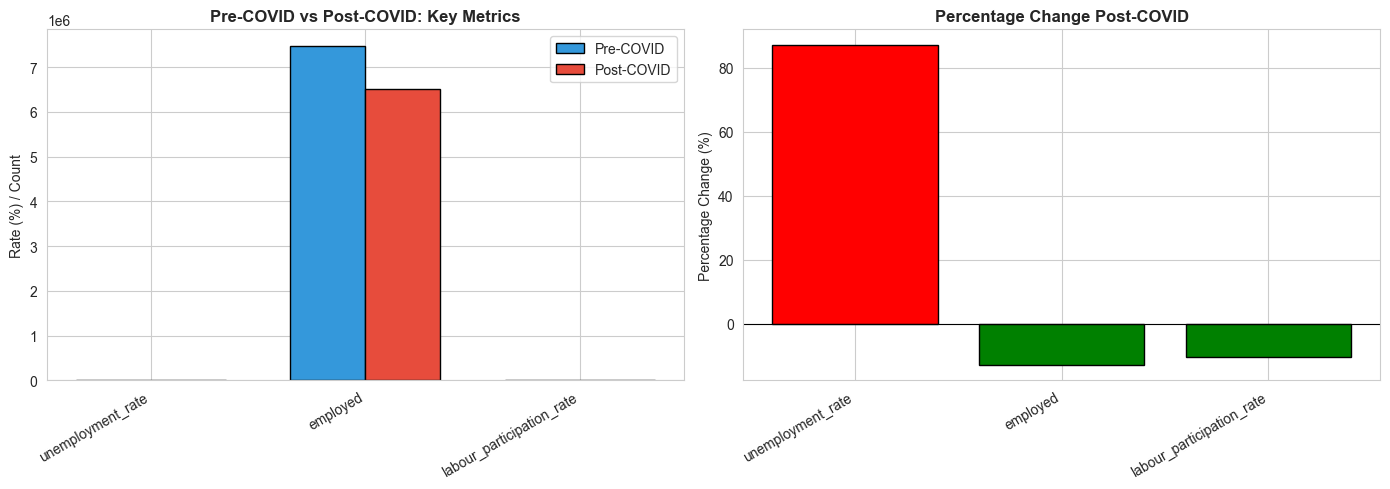


 Key COVID Impact Insights:
   unemployment_rate: increased by 86.9% (from 9.51 to 17.77)
   employed: decreased by 12.7% (from 7466027.87 to 6517203.34)
   labour_participation_rate: decreased by 10.4% (from 43.89 to 39.33)


In [43]:

if 'date' in df_clean.columns:
    covid_start = pd.to_datetime('2020-03-01')

    pre_covid = df_clean[df_clean['date'] < covid_start].copy()
    post_covid = df_clean[df_clean['date'] >= covid_start].copy()
    
    print(f"=== DATA SPLIT ===")
    print(f"Pre-COVID  (before Mar 2020):  {len(pre_covid)} rows")
    print(f"Post-COVID (Mar 2020 onwards): {len(post_covid)} rows")
    
    numeric_cols = [c for c in df_clean.select_dtypes(include=[np.number]).columns
                    if c not in ['year_month']]
    
    comparison = pd.DataFrame({
        'Pre-COVID_Mean': pre_covid[numeric_cols].mean().round(2),
        'Post-COVID_Mean': post_covid[numeric_cols].mean().round(2)
    })
    comparison['Change'] = (comparison['Post-COVID_Mean'] - comparison['Pre-COVID_Mean']).round(2)
    comparison['Pct_Change'] = ((comparison['Change'] / comparison['Pre-COVID_Mean']) * 100).round(1)
    
    print("\n=== PRE-COVID vs POST-COVID COMPARISON ===")
    print(comparison)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = range(len(comparison))
    width = 0.35
    axes[0].bar([i - width/2 for i in x], comparison['Pre-COVID_Mean'],
                width, label='Pre-COVID', color='#3498db', edgecolor='black')
    axes[0].bar([i + width/2 for i in x], comparison['Post-COVID_Mean'],
                width, label='Post-COVID', color='#e74c3c', edgecolor='black')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(comparison.index, rotation=30, ha='right')
    axes[0].set_ylabel('Rate (%) / Count')
    axes[0].set_title('Pre-COVID vs Post-COVID: Key Metrics', fontweight='bold')
    axes[0].legend()

    colors = ['green' if v < 0 else 'red' for v in comparison['Pct_Change']]
    axes[1].bar(range(len(comparison)), comparison['Pct_Change'], color=colors, edgecolor='black')
    axes[1].set_xticks(range(len(comparison)))
    axes[1].set_xticklabels(comparison.index, rotation=30, ha='right')
    axes[1].set_ylabel('Percentage Change (%)')
    axes[1].set_title('Percentage Change Post-COVID', fontweight='bold')
    axes[1].axhline(y=0, color='black', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()
    
    print("\n Key COVID Impact Insights:")
    for metric in comparison.index:
        pre = comparison.loc[metric, 'Pre-COVID_Mean']
        post = comparison.loc[metric, 'Post-COVID_Mean']
        pct = comparison.loc[metric, 'Pct_Change']
        direction = "increased" if post > pre else "decreased"
        print(f"   {metric}: {direction} by {abs(pct)}% (from {pre} to {post})")
else:
    print(" Date column not available for COVID comparison.")

=== TOP 10 REGIONS MOST AFFECTED BY COVID ===
                Pre_COVID  Post_COVID  Change
region                                       
Puducherry           1.59       38.96   37.36
Tamil Nadu           2.84       25.40   22.57
Jharkhand           14.28       36.35   22.07
Bihar               13.83       31.63   17.80
Karnataka            3.23       15.28   12.05
Haryana             22.94       34.65   11.72
Kerala               6.99       17.95   10.96
Telangana            4.66       15.44   10.79
Madhya Pradesh       4.74       14.07    9.33
Andhra Pradesh       5.04       13.58    8.54

=== TOP 10 REGIONS LEAST AFFECTED BY COVID ===
                  Pre_COVID  Post_COVID  Change
region                                         
Rajasthan             12.76       17.31    4.55
Punjab                10.99       14.62    3.63
Meghalaya              4.00        7.07    3.07
Uttarakhand            5.80        8.82    3.01
Sikkim                 6.26        9.07    2.81
Assam             

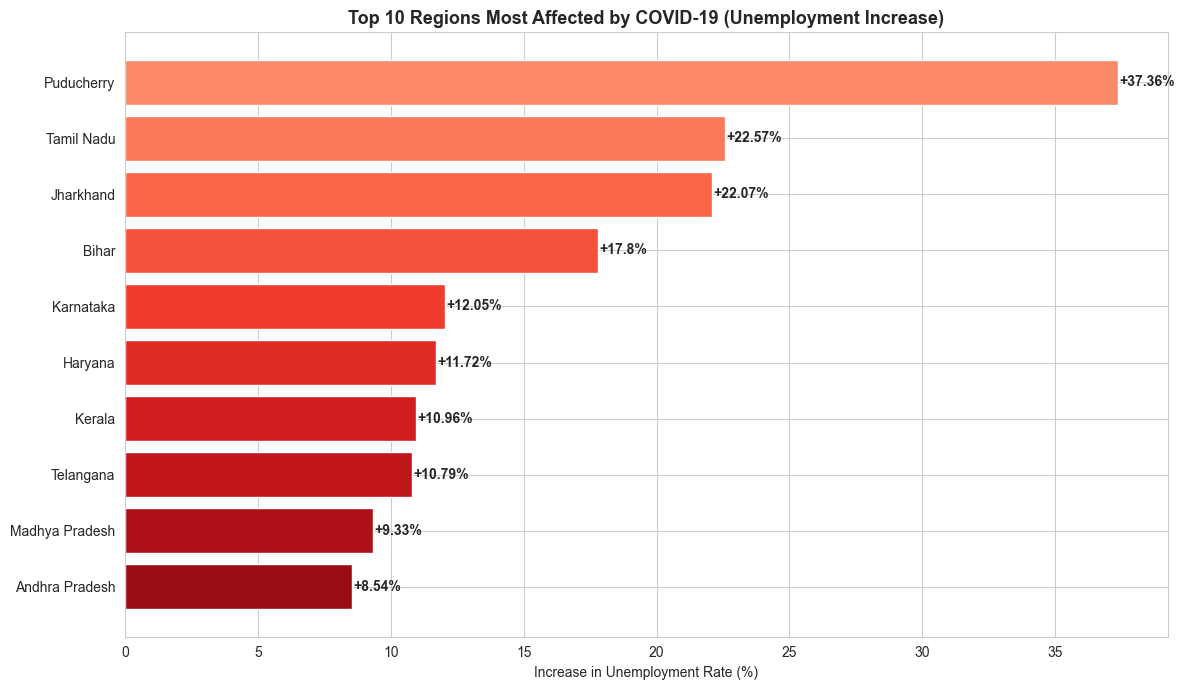


 Puducherry saw the biggest COVID impact: +37.36% unemployment increase.


In [44]:

if 'region' in df_clean.columns and 'date' in df_clean.columns:
    covid_start = pd.to_datetime('2020-03-01')

    pre = df_clean[df_clean['date'] < covid_start].groupby('region')['unemployment_rate'].mean()
    post = df_clean[df_clean['date'] >= covid_start].groupby('region')['unemployment_rate'].mean()

    covid_impact = pd.DataFrame({'Pre_COVID': pre, 'Post_COVID': post})
    covid_impact['Change'] = covid_impact['Post_COVID'] - covid_impact['Pre_COVID']
    covid_impact = covid_impact.dropna().sort_values('Change', ascending=False).round(2)
    
    print("=== TOP 10 REGIONS MOST AFFECTED BY COVID ===")
    print(covid_impact.head(10))
    
    print("\n=== TOP 10 REGIONS LEAST AFFECTED BY COVID ===")
    print(covid_impact.tail(10))
    
    top_affected = covid_impact.head(10)
    plt.figure(figsize=(12, 7))
    bars = plt.barh(range(len(top_affected)), top_affected['Change'],
                    color=plt.cm.Reds(np.linspace(0.4, 0.9, len(top_affected))))
    plt.yticks(range(len(top_affected)), top_affected.index)
    plt.xlabel('Increase in Unemployment Rate (%)')
    plt.title('Top 10 Regions Most Affected by COVID-19 (Unemployment Increase)',
              fontsize=13, fontweight='bold')
    plt.gca().invert_yaxis()
    
    for i, (bar, val) in enumerate(zip(bars, top_affected['Change'])):
        plt.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'+{val}%',
                va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n {covid_impact.index[0]} saw the biggest COVID impact: +{covid_impact.iloc[0]['Change']}% unemployment increase.")
else:
    print(" Required columns not available.")

=== UNEMPLOYMENT BY AREA TYPE ===
area
Urban    13.17
Rural    10.32
Name: unemployment_rate, dtype: float64


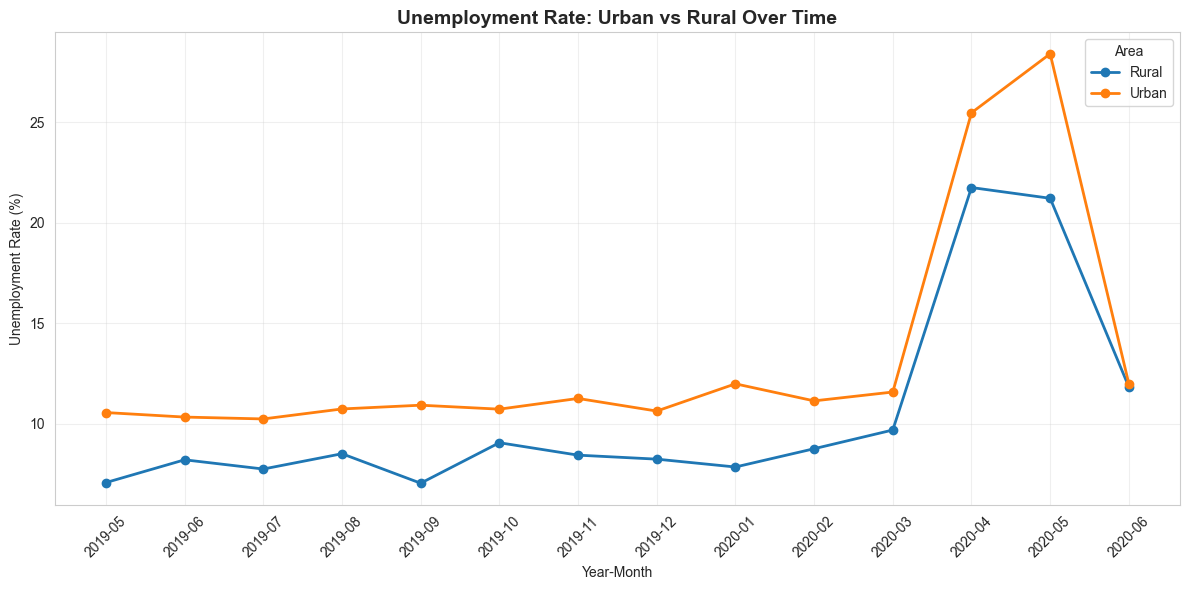


 Compare urban vs rural impact during and after COVID.


In [45]:

if 'area' in df_clean.columns:
    area_avg = df_clean.groupby('area')['unemployment_rate'].mean().round(2).sort_values(ascending=False)
    
    print("=== UNEMPLOYMENT BY AREA TYPE ===")
    print(area_avg)
    
    plt.figure(figsize=(12, 6))
    for area in df_clean['area'].unique():
        area_data = df_clean[df_clean['area'] == area].copy()
        area_monthly = area_data.groupby(area_data['date'].dt.to_period('M'))['unemployment_rate'].mean()
        plt.plot(area_monthly.index.astype(str), area_monthly.values,
                 marker='o', label=area, linewidth=2)
    
    plt.title('Unemployment Rate: Urban vs Rural Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Year-Month')
    plt.ylabel('Unemployment Rate (%)')
    plt.legend(title='Area')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n Compare urban vs rural impact during and after COVID.")
else:
    print(" No 'area' column found. Skipping urban/rural analysis.")
    print(f"   Available columns: {df_clean.columns.tolist()}")